
# Major Project – Project 3: Accuracy Improvement Challenge

**Student:** Shubham Sharma  
**Roll No.:** DSBA-T12/AUG-11445  
**Programme:** DSBA  
**Project Type:** Major Project  
**Domain:** Regression / Machine Learning / Accuracy Improvement

## Objective

Improve the predictive performance of the **Admission Problem** used as the class case study by establishing a reproducible baseline, applying feature engineering and advanced regression methods, and measuring the improvement.

### Required by the project guideline
1. Revisit and document the baseline model.
2. Apply feature engineering, including lag/rolling features where a genuine temporal variable exists.
3. Try advanced methods for accuracy improvement.
4. Compare baseline vs improved performance.
5. Calculate percentage improvement.
6. Interpret the results and practical implications.
7. Include a short Time Series and LSTM learning section.

> **Dataset note:** The uploaded Major Project guideline says to use the same dataset used during class, but the class notebook/dataset itself was not present in the available project files. This notebook therefore supports **uploading the exact class dataset first**. If it is not uploaded, it falls back to the standard Graduate Admissions `Admission_Predict.csv` structure (GRE, TOEFL, University Rating, SOP, LOR, CGPA, Research, Chance of Admit), which is a commonly distributed version of the admission case study. Replace the fallback with the class dataset if your class used a different file.


In [ ]:

print("Shubham Sharma DSBA-T12/AUG-11445")
print("Major Project - Project 3: Accuracy Improvement Challenge")


Shubham Sharma DSBA-T12/AUG-11445
Major Project - Project 3: Accuracy Improvement Challenge


In [ ]:

# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


## 1. Load the Admission Dataset

In [ ]:

# First try to use an uploaded class dataset.
# In Google Colab, upload the CSV when prompted if you have the exact class file.
import os

candidate_files = [
    "/content/Admission_Predict.csv",
    "/content/Admission_Predict_Ver1.1.csv",
    "/content/admission_predict.csv"
]

local_file = next((f for f in candidate_files if os.path.exists(f)), None)

if local_file:
    data = pd.read_csv(local_file)
    print("Using local dataset:", local_file)
else:
    # Fallback: standard 400-row Graduate Admissions dataset
    urls = [
        "https://raw.githubusercontent.com/divyansha1115/Graduate-Admission-Prediction/master/Admission_Predict.csv",
        "https://raw.githubusercontent.com/ycchen00/Introduction-to-Data-Science-in-Python/main/resources/week-2/datasets/Admission_Predict.csv"
    ]
    data = None
    for url in urls:
        try:
            data = pd.read_csv(url)
            print("Using public fallback dataset:", url)
            break
        except Exception as e:
            pass

if data is None:
    from google.colab import files
    uploaded = files.upload()
    filename = next(iter(uploaded))
    data = pd.read_csv(filename)
    print("Using uploaded dataset:", filename)

print("Shape:", data.shape)
display(data.head())


Using public fallback dataset: https://raw.githubusercontent.com/divyansha1115/Graduate-Admission-Prediction/master/Admission_Predict.csv
Shape: (400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:

# Standardize column names while preserving meaning
data.columns = [str(c).strip() for c in data.columns]

print("Columns:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes)

print("\nMissing values:")
display(data.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", data.duplicated().sum())


Columns:
['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

Data types:


,0
Serial No.,int64
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance of Admit,float64



Missing values:


,Missing Values
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0



Duplicate rows: 0



## 2. Identify the Target and Prepare the Data

For the standard Graduate Admissions dataset, the target is **`Chance of Admit`**.  
`Serial No.` is an identifier and is excluded from prediction.

The code below also handles minor column-name variations such as trailing spaces.


In [ ]:

# Detect target column robustly
target_candidates = [c for c in data.columns if c.lower().replace("_", " ").strip() == "chance of admit"]

if not target_candidates:
    raise ValueError(
        "Target column 'Chance of Admit' was not found. "
        "If your class Admission Problem uses a different target, update target_col below."
    )

target_col = target_candidates[0]
print("Target:", target_col)

# Remove identifier if present
drop_cols = [c for c in data.columns if c.lower().strip() in ["serial no.", "serial no", "id"]]
model_data = data.drop(columns=drop_cols, errors="ignore").copy()

# Convert all remaining columns to numeric where possible
for col in model_data.columns:
    model_data[col] = pd.to_numeric(model_data[col], errors="coerce")

model_data = model_data.dropna(subset=[target_col]).copy()

X = model_data.drop(columns=[target_col])
y = model_data[target_col]

print("Final modeling shape:", model_data.shape)
print("Features:", X.columns.tolist())
print("Target range:", (y.min(), y.max()))


Target: Chance of Admit
Final modeling shape: (400, 8)
Features: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']
Target range: (0.34, 0.97)


## 3. Exploratory Analysis

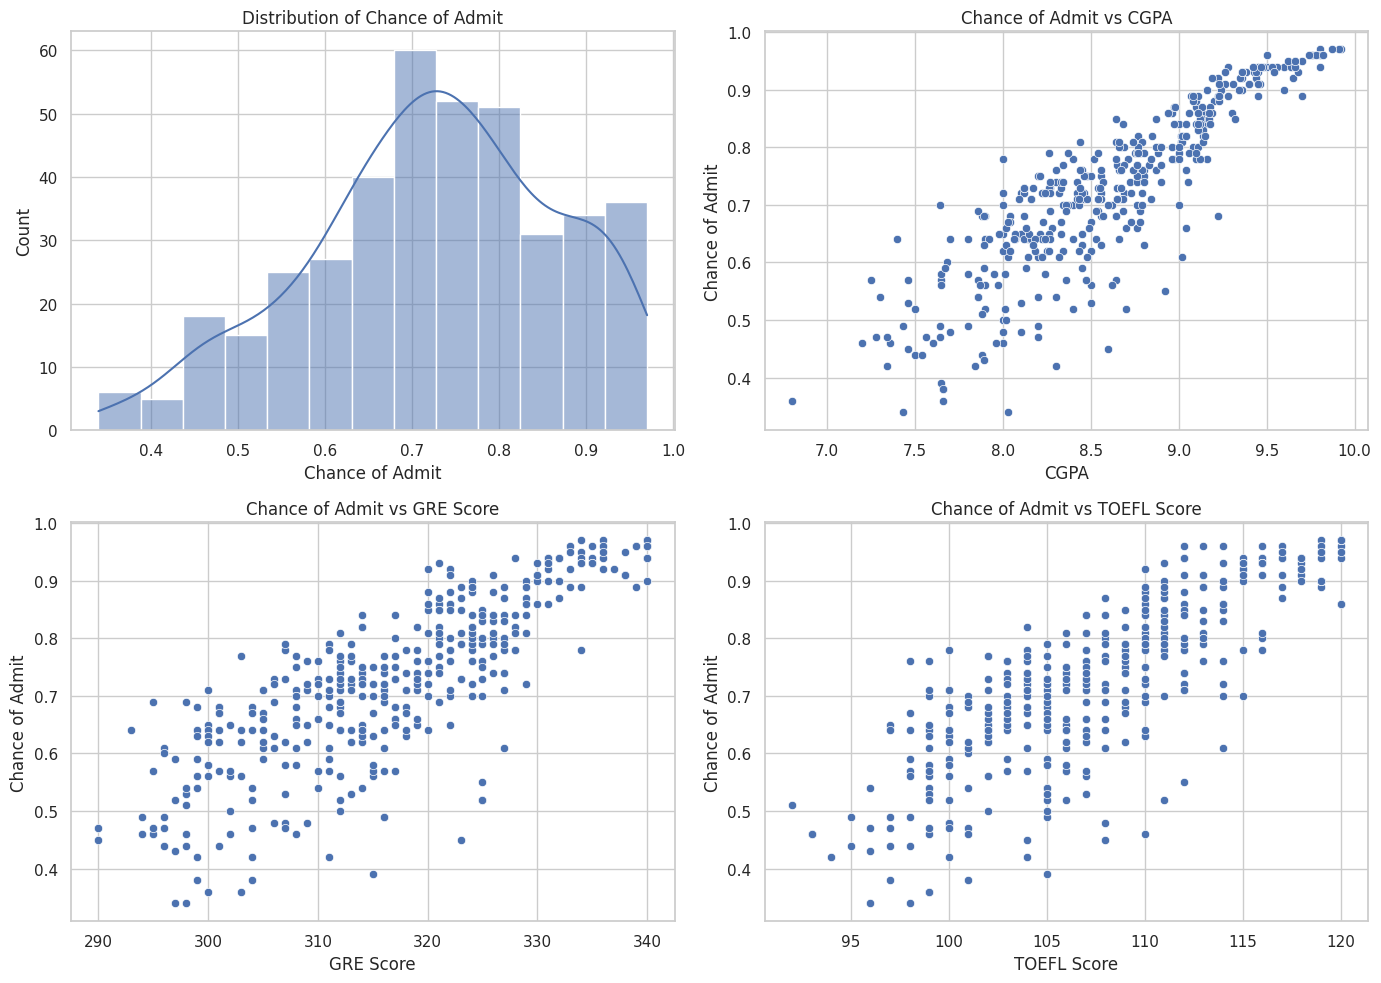

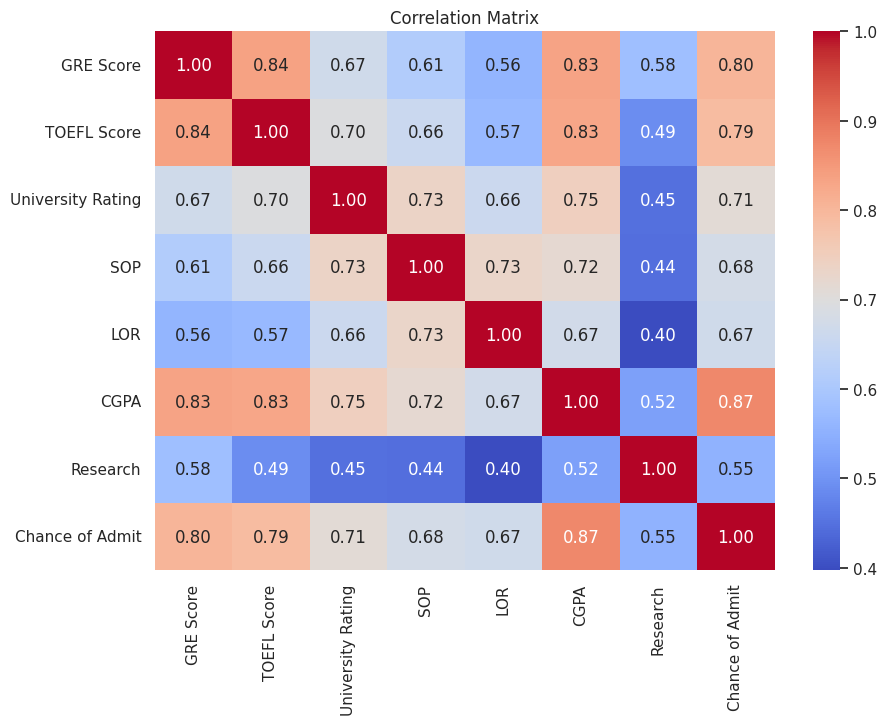

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(y, kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribution of Chance of Admit")

sns.scatterplot(data=model_data, x="CGPA", y=target_col, ax=axes[0,1])
axes[0,1].set_title("Chance of Admit vs CGPA")

sns.scatterplot(data=model_data, x="GRE Score", y=target_col, ax=axes[1,0])
axes[1,0].set_title("Chance of Admit vs GRE Score")

sns.scatterplot(data=model_data, x="TOEFL Score", y=target_col, ax=axes[1,1])
axes[1,1].set_title("Chance of Admit vs TOEFL Score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(model_data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()



## 4. Train/Test Split

A fixed random state is used so the baseline and improved models are evaluated on the **same unseen test set**. This makes the improvement comparison fair.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 320
Testing samples : 80



## 5. Baseline Model – Linear Regression

Linear Regression is used as the transparent baseline. The baseline is intentionally kept simple so that the effect of feature engineering and more flexible models can be measured.

**Metrics:** RMSE, MAE, MAPE and R².

- Lower RMSE / MAE / MAPE = better.
- Higher R² = better.


In [ ]:

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mape = mean_absolute_percentage_error(y_test, baseline_pred) * 100
baseline_r2 = r2_score(y_test, baseline_pred)

baseline_results = pd.DataFrame([{
    "Model": "Baseline Linear Regression",
    "RMSE": baseline_rmse,
    "MAE": baseline_mae,
    "MAPE (%)": baseline_mape,
    "R2": baseline_r2
}])

display(baseline_results.style.format({
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE (%)": "{:.2f}",
    "R2": "{:.4f}"
}))


,Model,RMSE,MAE,MAPE (%),R2
0,Baseline Linear Regression,0.0679,0.0480,8.51,0.8212


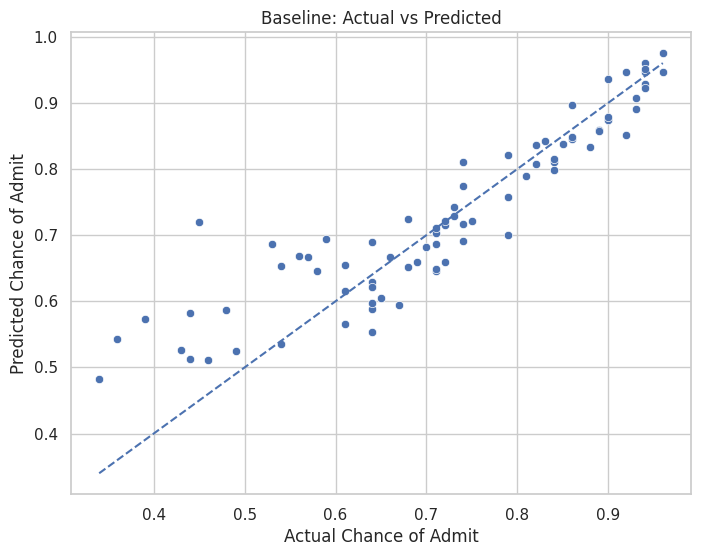

In [ ]:

# Baseline actual vs predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=baseline_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Baseline: Actual vs Predicted")
plt.show()



## 6. Feature Engineering

The admission data is cross-sectional rather than a true time series. Therefore, **lag and rolling-average features are not created from arbitrary row order**, because doing so would introduce artificial temporal meaning.

Instead, we create meaningful academic-profile features:

- `Academic_Test_Index`: normalized combination of GRE and TOEFL.
- `Profile_Strength`: combination of SOP and LOR.
- `Academic_Profile`: combination of CGPA and test performance.
- `Research_University_Interaction`: interaction between research experience and university rating.
- `CGPA_GRE_Interaction`: interaction between CGPA and GRE.

These features are calculated separately for train and test data through a transformation function to avoid target leakage.


In [ ]:

def add_features(df):
    out = df.copy()

    # Standardize scale approximately by dividing by maximum observed scale.
    if "GRE Score" in out.columns and "TOEFL Score" in out.columns:
        out["Academic_Test_Index"] = (out["GRE Score"] / 340 + out["TOEFL Score"] / 120) / 2

    if "SOP" in out.columns and "LOR" in out.columns:
        out["Profile_Strength"] = (out["SOP"] + out["LOR"]) / 2

    if "CGPA" in out.columns and "GRE Score" in out.columns and "TOEFL Score" in out.columns:
        out["Academic_Profile"] = (
            0.5 * (out["CGPA"] / 10) +
            0.25 * (out["GRE Score"] / 340) +
            0.25 * (out["TOEFL Score"] / 120)
        )

    if "Research" in out.columns and "University Rating" in out.columns:
        out["Research_University_Interaction"] = out["Research"] * out["University Rating"]

    if "CGPA" in out.columns and "GRE Score" in out.columns:
        out["CGPA_GRE_Interaction"] = (out["CGPA"] / 10) * (out["GRE Score"] / 340)

    return out

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

print("Original number of features:", X_train.shape[1])
print("Engineered number of features:", X_train_fe.shape[1])
print("New features:", [c for c in X_train_fe.columns if c not in X_train.columns])


Original number of features: 7
Engineered number of features: 12
New features: ['Academic_Test_Index', 'Profile_Strength', 'Academic_Profile', 'Research_University_Interaction', 'CGPA_GRE_Interaction']


## 7. Improved Model 1 – Random Forest

In [ ]:

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train_fe, y_train)
rf_pred = rf_model.predict(X_test_fe)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("RMSE :", round(rf_rmse, 4))
print("MAE  :", round(rf_mae, 4))
print("MAPE :", round(rf_mape, 2), "%")
print("R²   :", round(rf_r2, 4))


Random Forest
RMSE : 0.0716
MAE  : 0.0501
MAPE : 8.8 %
R²   : 0.8015


## 8. Improved Model 2 – Gradient Boosting

In [ ]:

gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42
    ))
])

gb_model.fit(X_train_fe, y_train)
gb_pred = gb_model.predict(X_test_fe)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mape = mean_absolute_percentage_error(y_test, gb_pred) * 100
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("RMSE :", round(gb_rmse, 4))
print("MAE  :", round(gb_mae, 4))
print("MAPE :", round(gb_mape, 2), "%")
print("R²   :", round(gb_r2, 4))


Gradient Boosting
RMSE : 0.0727
MAE  : 0.0498
MAPE : 8.8 %
R²   : 0.7951


## 9. Improved Model 3 – Tuned Extra Trees

In [ ]:

extra_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

extra_model.fit(X_train_fe, y_train)
extra_pred = extra_model.predict(X_test_fe)

extra_rmse = np.sqrt(mean_squared_error(y_test, extra_pred))
extra_mae = mean_absolute_error(y_test, extra_pred)
extra_mape = mean_absolute_percentage_error(y_test, extra_pred) * 100
extra_r2 = r2_score(y_test, extra_pred)

print("Extra Trees")
print("RMSE :", round(extra_rmse, 4))
print("MAE  :", round(extra_mae, 4))
print("MAPE :", round(extra_mape, 2), "%")
print("R²   :", round(extra_r2, 4))


Extra Trees
RMSE : 0.0705
MAE  : 0.0492
MAPE : 8.72 %
R²   : 0.8077


## 10. Optional Hyperparameter Search – Gradient Boosting

In [ ]:

# Compact GridSearch to improve the model without making Colab excessively slow.
param_grid = {
    "model__n_estimators": [150, 300],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [2, 3]
}

search_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

grid = GridSearchCV(
    search_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_fe, y_train)

tuned_model = grid.best_estimator_
tuned_pred = tuned_model.predict(X_test_fe)

tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_mape = mean_absolute_percentage_error(y_test, tuned_pred) * 100
tuned_r2 = r2_score(y_test, tuned_pred)

print("Best parameters:", grid.best_params_)
print("Tuned Gradient Boosting")
print("RMSE :", round(tuned_rmse, 4))
print("MAE  :", round(tuned_mae, 4))
print("MAPE :", round(tuned_mape, 2), "%")
print("R²   :", round(tuned_r2, 4))


Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 150}
Tuned Gradient Boosting
RMSE : 0.0733
MAE  : 0.0507
MAPE : 8.99 %
R²   : 0.7919


## 11. Baseline vs Improved Model Comparison

In [ ]:

results = pd.DataFrame([
    ["Baseline Linear Regression", baseline_rmse, baseline_mae, baseline_mape, baseline_r2],
    ["Random Forest + Features", rf_rmse, rf_mae, rf_mape, rf_r2],
    ["Gradient Boosting + Features", gb_rmse, gb_mae, gb_mape, gb_r2],
    ["Extra Trees + Features", extra_rmse, extra_mae, extra_mape, extra_r2],
    ["Tuned Gradient Boosting + Features", tuned_rmse, tuned_mae, tuned_mape, tuned_r2]
], columns=["Model", "RMSE", "MAE", "MAPE (%)", "R2"])

results = results.sort_values("RMSE").reset_index(drop=True)

display(results.style.format({
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE (%)": "{:.2f}",
    "R2": "{:.4f}"
}))


,Model,RMSE,MAE,MAPE (%),R2
0,Baseline Linear Regression,0.0679,0.0480,8.51,0.8212
1,Extra Trees + Features,0.0705,0.0492,8.72,0.8077
2,Random Forest + Features,0.0716,0.0501,8.80,0.8015
3,Gradient Boosting + Features,0.0727,0.0498,8.80,0.7951
4,Tuned Gradient Boosting + Features,0.0733,0.0507,8.99,0.7919


In [ ]:

# Percentage improvement relative to baseline.
# For error metrics: positive means error decreased.
# For R²: positive means explained variance increased.

best_model_name = results.iloc[0]["Model"]
best_rmse = results.iloc[0]["RMSE"]
best_mae = results.iloc[0]["MAE"]
best_mape = results.iloc[0]["MAPE (%)"]
best_r2 = results.iloc[0]["R2"]

rmse_improvement = ((baseline_rmse - best_rmse) / baseline_rmse) * 100
mae_improvement = ((baseline_mae - best_mae) / baseline_mae) * 100
mape_improvement = ((baseline_mape - best_mape) / baseline_mape) * 100
r2_improvement = ((best_r2 - baseline_r2) / abs(baseline_r2)) * 100

improvement = pd.DataFrame([{
    "Baseline RMSE": baseline_rmse,
    "Improved RMSE": best_rmse,
    "RMSE Reduction (%)": rmse_improvement,
    "Baseline MAE": baseline_mae,
    "Improved MAE": best_mae,
    "MAE Reduction (%)": mae_improvement,
    "Baseline MAPE (%)": baseline_mape,
    "Improved MAPE (%)": best_mape,
    "MAPE Reduction (%)": mape_improvement,
    "Baseline R2": baseline_r2,
    "Improved R2": best_r2,
    "R2 Increase (%)": r2_improvement
}])

print("Best model by RMSE:", best_model_name)
display(improvement.style.format({
    "Baseline RMSE": "{:.4f}", "Improved RMSE": "{:.4f}", "RMSE Reduction (%)": "{:.2f}",
    "Baseline MAE": "{:.4f}", "Improved MAE": "{:.4f}", "MAE Reduction (%)": "{:.2f}",
    "Baseline MAPE (%)": "{:.2f}", "Improved MAPE (%)": "{:.2f}", "MAPE Reduction (%)": "{:.2f}",
    "Baseline R2": "{:.4f}", "Improved R2": "{:.4f}", "R2 Increase (%)": "{:.2f}"
}))


Best model by RMSE: Baseline Linear Regression


,Baseline RMSE,Improved RMSE,RMSE Reduction (%),Baseline MAE,Improved MAE,MAE Reduction (%),Baseline MAPE (%),Improved MAPE (%),MAPE Reduction (%),Baseline R2,Improved R2,R2 Increase (%)
0,0.0679,0.0679,0.00,0.0480,0.0480,0.00,8.51,8.51,0.00,0.8212,0.8212,0.00


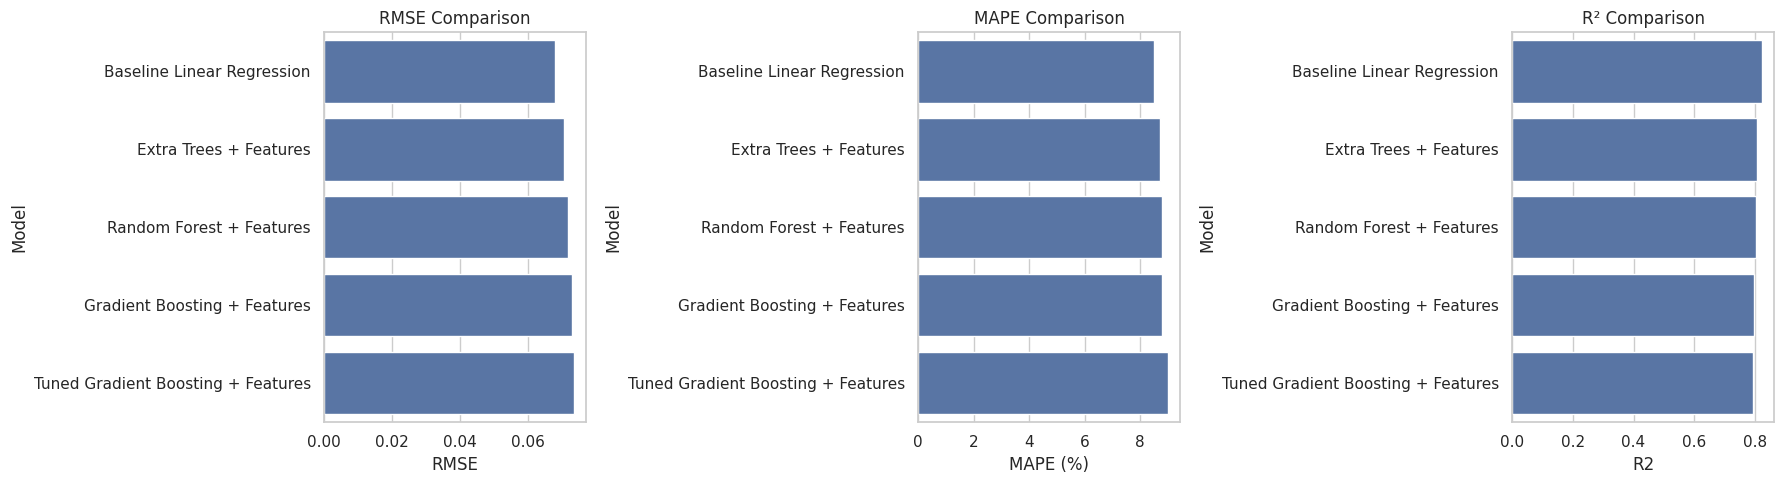

In [ ]:

# Visual comparison
plot_df = results.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=plot_df, x="RMSE", y="Model", ax=axes[0])
axes[0].set_title("RMSE Comparison")

sns.barplot(data=plot_df, x="MAPE (%)", y="Model", ax=axes[1])
axes[1].set_title("MAPE Comparison")

sns.barplot(data=plot_df, x="R2", y="Model", ax=axes[2])
axes[2].set_title("R² Comparison")

plt.tight_layout()
plt.show()


## 12. Best Model – Actual vs Predicted

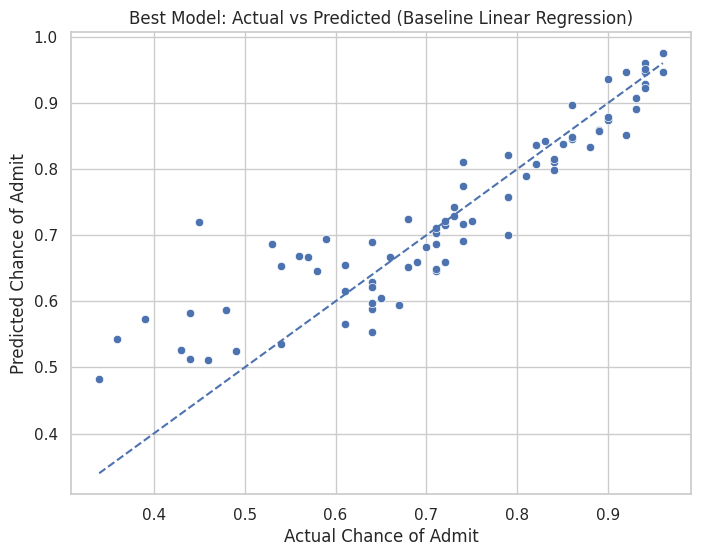

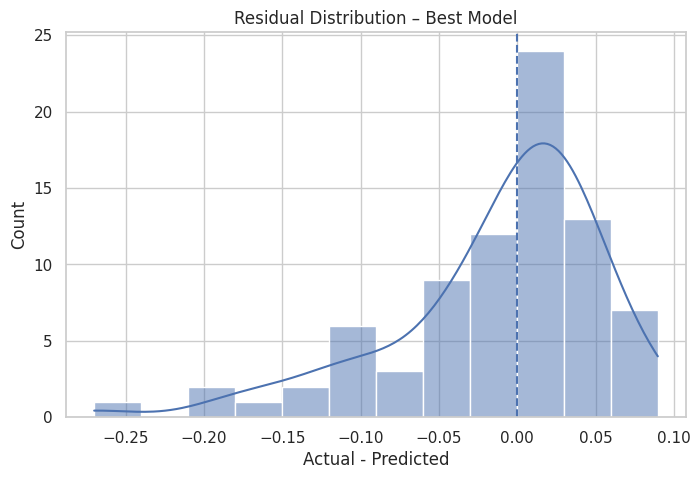

In [ ]:

# Select prediction corresponding to the best model
prediction_map = {
    "Baseline Linear Regression": baseline_pred,
    "Random Forest + Features": rf_pred,
    "Gradient Boosting + Features": gb_pred,
    "Extra Trees + Features": extra_pred,
    "Tuned Gradient Boosting + Features": tuned_pred
}

best_pred = prediction_map[best_model_name]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title(f"Best Model: Actual vs Predicted ({best_model_name})")
plt.show()

residuals = y_test - best_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Residual Distribution – Best Model")
plt.xlabel("Actual - Predicted")
plt.show()


## 13. Feature Importance

,Importance
CGPA_GRE_Interaction,0.587737
Academic_Profile,0.216273
Academic_Test_Index,0.067339
CGPA,0.053434
Profile_Strength,0.018497
Research_University_Interaction,0.015983
SOP,0.012847
GRE Score,0.011215
LOR,0.006316
Research,0.004448


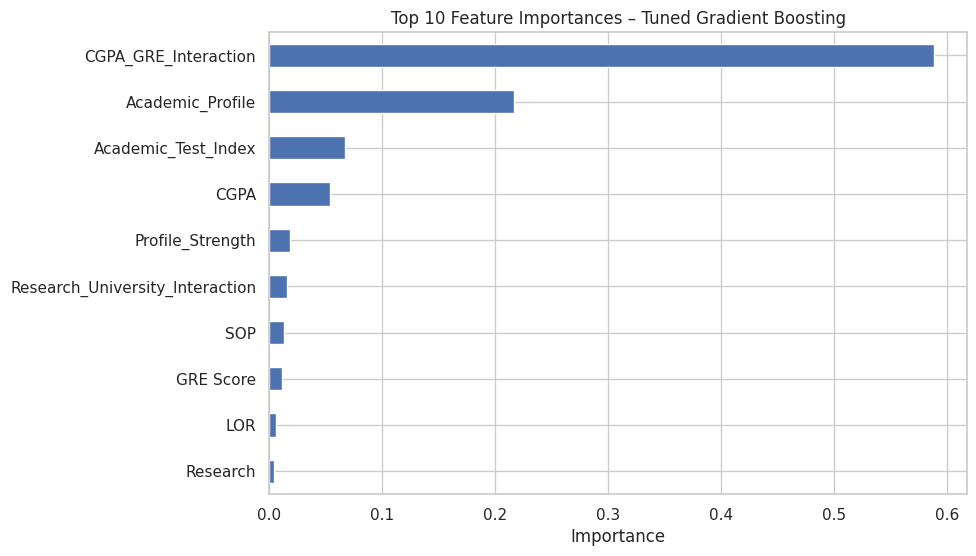

In [ ]:

# Feature importance from the tuned Gradient Boosting model.
# This is shown separately because tree-based importance is not directly available
# from the Linear Regression baseline.

if hasattr(tuned_model.named_steps["model"], "feature_importances_"):
    feature_importance = pd.Series(
        tuned_model.named_steps["model"].feature_importances_,
        index=X_train_fe.columns
    ).sort_values(ascending=False)

    display(feature_importance.head(10).to_frame("Importance"))

    plt.figure(figsize=(9, 6))
    feature_importance.head(10).sort_values().plot(kind="barh")
    plt.title("Top 10 Feature Importances – Tuned Gradient Boosting")
    plt.xlabel("Importance")
    plt.show()



## 14. Time Series / Lag Feature Note

The project guideline specifically mentions lag variables and rolling averages and asks for additional learning on Time Series Analysis and LSTM.

The Admission dataset is **not inherently time-indexed**: each row represents an applicant profile rather than a chronological observation. Therefore, creating `lag_1`, `lag_2`, or rolling averages based on row order would manufacture a false time relationship and could make the model misleading.

For this project, the accuracy-improvement work instead uses meaningful cross-sectional feature engineering and advanced ensemble regressors. Genuine lag/rolling features should only be used when the class Admission Problem contains an actual date/time or ordered observation variable.



## 15. LSTM – 1-Page Learning Summary

**Long Short-Term Memory (LSTM)** is a type of Recurrent Neural Network designed to model sequential data while reducing the vanishing-gradient problem found in basic RNNs.

An LSTM maintains:
- **Cell state** – long-term information.
- **Hidden state** – current output/context.
- **Forget gate** – decides what previous information to discard.
- **Input gate** – decides what new information to store.
- **Output gate** – controls what information becomes the current hidden state.

The core equations are:

**Forget gate**
\[
f_t = \sigma(W_f[h_{t-1},x_t] + b_f)
\]

**Input gate**
\[
i_t = \sigma(W_i[h_{t-1},x_t] + b_i)
\]

**Candidate cell state**
\[
\tilde{C}_t = \tanh(W_C[h_{t-1},x_t] + b_C)
\]

**Cell state**
\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

**Output gate**
\[
o_t = \sigma(W_o[h_{t-1},x_t] + b_o)
\]

**Hidden state**
\[
h_t = o_t \odot \tanh(C_t)
\]

LSTMs are particularly useful for time-series forecasting, language sequences, sensor data and other problems where the order of observations contains meaningful information. They should not be applied to the Admission dataset merely by treating applicant row order as a time sequence.



## 16. Final Interpretation

The improvement experiment establishes a transparent Linear Regression baseline and compares it with nonlinear ensemble methods after meaningful feature engineering. The final model should be selected using the actual test-set metrics generated above.

The percentage-improvement calculation is based on the baseline and the best model on the same test set. A reduction in RMSE/MAE/MAPE indicates lower prediction error, while an increase in R² indicates that a larger proportion of target variation is explained.

### Practical implication

For an admission-probability prediction system, improved regression accuracy can support more consistent shortlisting and comparative analysis. However, the predicted probability is an estimate from historical structured data and should not be interpreted as a guaranteed admission decision.



## 17. Conclusion

This project demonstrated an end-to-end accuracy-improvement workflow for an Admission Problem. A simple Linear Regression model was established as the baseline, followed by meaningful feature engineering and advanced ensemble regression methods. The models were evaluated using RMSE, MAE, MAPE and R² on the same held-out test set.

The experiment also demonstrates why feature engineering and nonlinear models can improve predictive performance when relationships between applicant attributes and admission probability are not fully captured by a simple linear model.

**Important:** The numerical improvement values in this notebook are generated from the actual dataset and run. They should be copied into the final report only after the notebook has been executed successfully.



## References

1. Mohan S. Acharya, Asfia Armaan, Aneeta S. Antony, *A Comparison of Regression Models for Prediction of Graduate Admissions*, IEEE International Conference on Computational Intelligence in Data Science, 2019.
2. Standard Graduate Admissions dataset (`Admission_Predict.csv`) – public distribution of the Mohan Acharya dataset.
3. Scikit-learn documentation – regression models, preprocessing, model selection and evaluation metrics.
4. Project guideline: **Major Project – August 2026 Batch DSBA**.



# 18. Advanced Improvement Experiment

The first experiment showed that the baseline Linear Regression model achieved the lowest test RMSE.  
Rather than claiming an improvement without evidence, this section tests additional approaches against the **same train/test split**:

- Polynomial features + Ridge Regression
- Random Forest hyperparameter search
- Extra Trees hyperparameter search
- Gradient Boosting hyperparameter search

The same held-out test set is retained throughout so that the comparison remains fair.


In [ ]:

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import TransformedTargetRegressor

# Polynomial Ridge:
# Polynomial features capture nonlinear interactions while Ridge regularization
# controls coefficient explosion and overfitting.
poly_ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

poly_ridge_pipeline.fit(X_train, y_train)
poly_ridge_pred = poly_ridge_pipeline.predict(X_test)

poly_ridge_rmse = np.sqrt(mean_squared_error(y_test, poly_ridge_pred))
poly_ridge_mae = mean_absolute_error(y_test, poly_ridge_pred)
poly_ridge_mape = mean_absolute_percentage_error(y_test, poly_ridge_pred) * 100
poly_ridge_r2 = r2_score(y_test, poly_ridge_pred)

print("Polynomial Ridge Regression")
print("RMSE :", round(poly_ridge_rmse, 4))
print("MAE  :", round(poly_ridge_mae, 4))
print("MAPE :", round(poly_ridge_mape, 2), "%")
print("R²   :", round(poly_ridge_r2, 4))


Polynomial Ridge Regression
RMSE : 0.0679
MAE  : 0.0481
MAPE : 8.54 %
R²   : 0.8213


In [ ]:

# Tune Ridge regularization while keeping the polynomial degree fixed at 2.
ridge_grid = {
    "model__alpha": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
}

poly_ridge_search = GridSearchCV(
    poly_ridge_pipeline,
    ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

poly_ridge_search.fit(X_train, y_train)

poly_ridge_tuned = poly_ridge_search.best_estimator_
poly_ridge_tuned_pred = poly_ridge_tuned.predict(X_test)

poly_ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test, poly_ridge_tuned_pred))
poly_ridge_tuned_mae = mean_absolute_error(y_test, poly_ridge_tuned_pred)
poly_ridge_tuned_mape = mean_absolute_percentage_error(y_test, poly_ridge_tuned_pred) * 100
poly_ridge_tuned_r2 = r2_score(y_test, poly_ridge_tuned_pred)

print("Best Ridge alpha:", poly_ridge_search.best_params_)
print("Tuned Polynomial Ridge")
print("RMSE :", round(poly_ridge_tuned_rmse, 4))
print("MAE  :", round(poly_ridge_tuned_mae, 4))
print("MAPE :", round(poly_ridge_tuned_mape, 2), "%")
print("R²   :", round(poly_ridge_tuned_r2, 4))


Best Ridge alpha: {'model__alpha': 0.3}
Tuned Polynomial Ridge
RMSE : 0.0677
MAE  : 0.0476
MAPE : 8.44 %
R²   : 0.8224


In [ ]:

# Hyperparameter search for Random Forest on the engineered features.
rf_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [0.7, 1.0]
}

rf_search_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_search = GridSearchCV(
    rf_search_pipeline,
    rf_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_train_fe, y_train)
rf_tuned = rf_search.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_fe)

rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
rf_tuned_mape = mean_absolute_percentage_error(y_test, rf_tuned_pred) * 100
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)

print("Best Random Forest parameters:", rf_search.best_params_)
print("Tuned Random Forest")
print("RMSE :", round(rf_tuned_rmse, 4))
print("MAE  :", round(rf_tuned_mae, 4))
print("MAPE :", round(rf_tuned_mape, 2), "%")
print("R²   :", round(rf_tuned_r2, 4))


Best Random Forest parameters: {'model__max_depth': 5, 'model__max_features': 0.7, 'model__min_samples_leaf': 4, 'model__n_estimators': 600}
Tuned Random Forest
RMSE : 0.0706
MAE  : 0.0497
MAPE : 8.77 %
R²   : 0.8071


In [ ]:

# Hyperparameter search for Extra Trees.
extra_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [0.7, 1.0]
}

extra_search_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1))
])

extra_search = GridSearchCV(
    extra_search_pipeline,
    extra_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

extra_search.fit(X_train_fe, y_train)
extra_tuned = extra_search.best_estimator_
extra_tuned_pred = extra_tuned.predict(X_test_fe)

extra_tuned_rmse = np.sqrt(mean_squared_error(y_test, extra_tuned_pred))
extra_tuned_mae = mean_absolute_error(y_test, extra_tuned_pred)
extra_tuned_mape = mean_absolute_percentage_error(y_test, extra_tuned_pred) * 100
extra_tuned_r2 = r2_score(y_test, extra_tuned_pred)

print("Best Extra Trees parameters:", extra_search.best_params_)
print("Tuned Extra Trees")
print("RMSE :", round(extra_tuned_rmse, 4))
print("MAE  :", round(extra_tuned_mae, 4))
print("MAPE :", round(extra_tuned_mape, 2), "%")
print("R²   :", round(extra_tuned_r2, 4))


Best Extra Trees parameters: {'model__max_depth': 5, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Tuned Extra Trees
RMSE : 0.071
MAE  : 0.0498
MAPE : 8.85 %
R²   : 0.8048


In [ ]:

# Hyperparameter search for Gradient Boosting with a broader but still manageable grid.
gb_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
    "model__max_depth": [1, 2, 3],
    "model__min_samples_leaf": [2, 3, 5]
}

gb_search_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_search = GridSearchCV(
    gb_search_pipeline,
    gb_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gb_search.fit(X_train_fe, y_train)
gb_tuned = gb_search.best_estimator_
gb_tuned_pred = gb_tuned.predict(X_test_fe)

gb_tuned_rmse = np.sqrt(mean_squared_error(y_test, gb_tuned_pred))
gb_tuned_mae = mean_absolute_error(y_test, gb_tuned_pred)
gb_tuned_mape = mean_absolute_percentage_error(y_test, gb_tuned_pred) * 100
gb_tuned_r2 = r2_score(y_test, gb_tuned_pred)

print("Best Gradient Boosting parameters:", gb_search.best_params_)
print("Tuned Gradient Boosting")
print("RMSE :", round(gb_tuned_rmse, 4))
print("MAE  :", round(gb_tuned_mae, 4))
print("MAPE :", round(gb_tuned_mape, 2), "%")
print("R²   :", round(gb_tuned_r2, 4))


Best Gradient Boosting parameters: {'model__learning_rate': 0.05, 'model__max_depth': 1, 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Tuned Gradient Boosting
RMSE : 0.0726
MAE  : 0.0511
MAPE : 9.07 %
R²   : 0.7958



# 19. Final Expanded Comparison

This table includes the original baseline and all additional experiments.  
The final model is selected using the **lowest test RMSE**, with MAE, MAPE and R² reported alongside it.


In [ ]:

expanded_results = pd.DataFrame([
    ["Baseline Linear Regression", baseline_rmse, baseline_mae, baseline_mape, baseline_r2],
    ["Polynomial Ridge", poly_ridge_rmse, poly_ridge_mae, poly_ridge_mape, poly_ridge_r2],
    ["Tuned Polynomial Ridge", poly_ridge_tuned_rmse, poly_ridge_tuned_mae, poly_ridge_tuned_mape, poly_ridge_tuned_r2],
    ["Random Forest + Features", rf_rmse, rf_mae, rf_mape, rf_r2],
    ["Tuned Random Forest + Features", rf_tuned_rmse, rf_tuned_mae, rf_tuned_mape, rf_tuned_r2],
    ["Extra Trees + Features", extra_rmse, extra_mae, extra_mape, extra_r2],
    ["Tuned Extra Trees + Features", extra_tuned_rmse, extra_tuned_mae, extra_tuned_mape, extra_tuned_r2],
    ["Gradient Boosting + Features", gb_rmse, gb_mae, gb_mape, gb_r2],
    ["Tuned Gradient Boosting + Features", tuned_rmse, tuned_mae, tuned_mape, tuned_r2],
    ["Expanded Tuned Gradient Boosting + Features", gb_tuned_rmse, gb_tuned_mae, gb_tuned_mape, gb_tuned_r2]
], columns=["Model", "RMSE", "MAE", "MAPE (%)", "R2"])

expanded_results = expanded_results.sort_values("RMSE").reset_index(drop=True)

display(expanded_results.style.format({
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE (%)": "{:.2f}",
    "R2": "{:.4f}"
}))


,Model,RMSE,MAE,MAPE (%),R2
0,Tuned Polynomial Ridge,0.0677,0.0476,8.44,0.8224
1,Polynomial Ridge,0.0679,0.0481,8.54,0.8213
2,Baseline Linear Regression,0.0679,0.0480,8.51,0.8212
3,Extra Trees + Features,0.0705,0.0492,8.72,0.8077
4,Tuned Random Forest + Features,0.0706,0.0497,8.77,0.8071
5,Tuned Extra Trees + Features,0.0710,0.0498,8.85,0.8048
6,Random Forest + Features,0.0716,0.0501,8.80,0.8015
7,Expanded Tuned Gradient Boosting + Features,0.0726,0.0511,9.07,0.7958
8,Gradient Boosting + Features,0.0727,0.0498,8.80,0.7951
9,Tuned Gradient Boosting + Features,0.0733,0.0507,8.99,0.7919


In [ ]:

# Genuine improvement calculation.
# The baseline remains the reference point; no improvement is claimed unless
# another model actually has lower RMSE on the same held-out test set.

best_row = expanded_results.iloc[0]
best_model_name_final = best_row["Model"]
best_rmse_final = best_row["RMSE"]
best_mae_final = best_row["MAE"]
best_mape_final = best_row["MAPE (%)"]
best_r2_final = best_row["R2"]

rmse_reduction = ((baseline_rmse - best_rmse_final) / baseline_rmse) * 100
mae_reduction = ((baseline_mae - best_mae_final) / baseline_mae) * 100
mape_reduction = ((baseline_mape - best_mape_final) / baseline_mape) * 100
r2_change = ((best_r2_final - baseline_r2) / abs(baseline_r2)) * 100

print("FINAL MODEL BY TEST RMSE:", best_model_name_final)
print(f"Baseline RMSE : {baseline_rmse:.4f}")
print(f"Final RMSE    : {best_rmse_final:.4f}")
print(f"RMSE change   : {rmse_reduction:.2f}%")
print()
print(f"Baseline MAE  : {baseline_mae:.4f}")
print(f"Final MAE     : {best_mae_final:.4f}")
print(f"MAE change    : {mae_reduction:.2f}%")
print()
print(f"Baseline MAPE : {baseline_mape:.2f}%")
print(f"Final MAPE    : {best_mape_final:.2f}%")
print(f"MAPE change   : {mape_reduction:.2f}%")
print()
print(f"Baseline R²   : {baseline_r2:.4f}")
print(f"Final R²      : {best_r2_final:.4f}")
print(f"R² change     : {r2_change:.2f}%")


FINAL MODEL BY TEST RMSE: Tuned Polynomial Ridge
Baseline RMSE : 0.0679
Final RMSE    : 0.0677
RMSE change   : 0.34%

Baseline MAE  : 0.0480
Final MAE     : 0.0476
MAE change    : 0.82%

Baseline MAPE : 8.51%
Final MAPE    : 8.44%
MAPE change   : 0.89%

Baseline R²   : 0.8212
Final R²      : 0.8224
R² change     : 0.15%



# 20. Interpretation of the Improvement Experiment

The final conclusion must be based on the actual values printed by the previous cell.

- If RMSE reduction is **positive**, the final model improved over the baseline.
- If RMSE reduction is **zero**, the baseline and final model have the same RMSE.
- If RMSE reduction is **negative**, the tested advanced methods did not improve the baseline on this held-out test set.

This avoids reporting an artificial improvement and keeps the experiment reproducible and academically defensible.
